**Explainable Skin Lesion Classification Framework**

**Import Libraries**

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
os.makedirs("/kaggle/working/figures", exist_ok=True)
os.makedirs("/kaggle/working/results", exist_ok=True)


import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

warnings.filterwarnings("ignore")

print("TensorFlow Version:", tf.__version__)

2026-06-06 14:43:32.217896: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780757012.398400      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780757012.452841      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780757012.897456      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780757012.897496      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780757012.897498      58 computation_placer.cc:177] computation placer alr

TensorFlow Version: 2.19.0


**Load Metaset**

In [2]:
metadata_path = "/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_metadata.csv"

metadata = pd.read_csv(metadata_path)

print("Dataset Shape:", metadata.shape)
metadata.head()

Dataset Shape: (10015, 7)


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


**Dataset Overview and Class Distribution**

Total Images: 10015
Number of Classes: 7


dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64

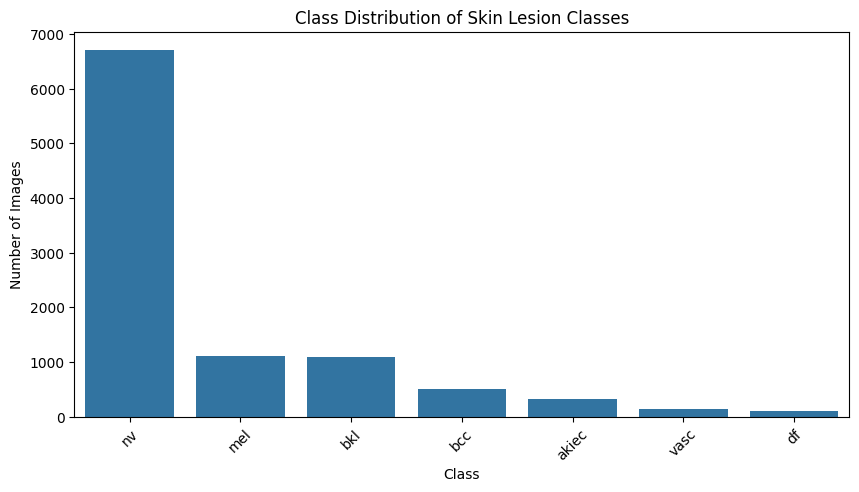

In [3]:
class_names = {
    'akiec': 'Actinic keratoses',
    'bcc': 'Basal cell carcinoma',
    'bkl': 'Benign keratosis-like lesions',
    'df': 'Dermatofibroma',
    'mel': 'Melanoma',
    'nv': 'Melanocytic nevi',
    'vasc': 'Vascular lesions'
}

metadata['class_name'] = metadata['dx'].map(class_names)

print("Total Images:", len(metadata))
print("Number of Classes:", metadata['dx'].nunique())

display(metadata['dx'].value_counts())

plt.figure(figsize=(10,5))
sns.countplot(x=metadata['dx'], order=metadata['dx'].value_counts().index)
plt.title("Class Distribution of Skin Lesion Classes")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.savefig("/kaggle/working/figures/class_distribution.png", dpi=300, bbox_inches="tight")

**Image Paths and Sample Images**

Total Image Paths Found: 10015
Missing Image Paths: 0


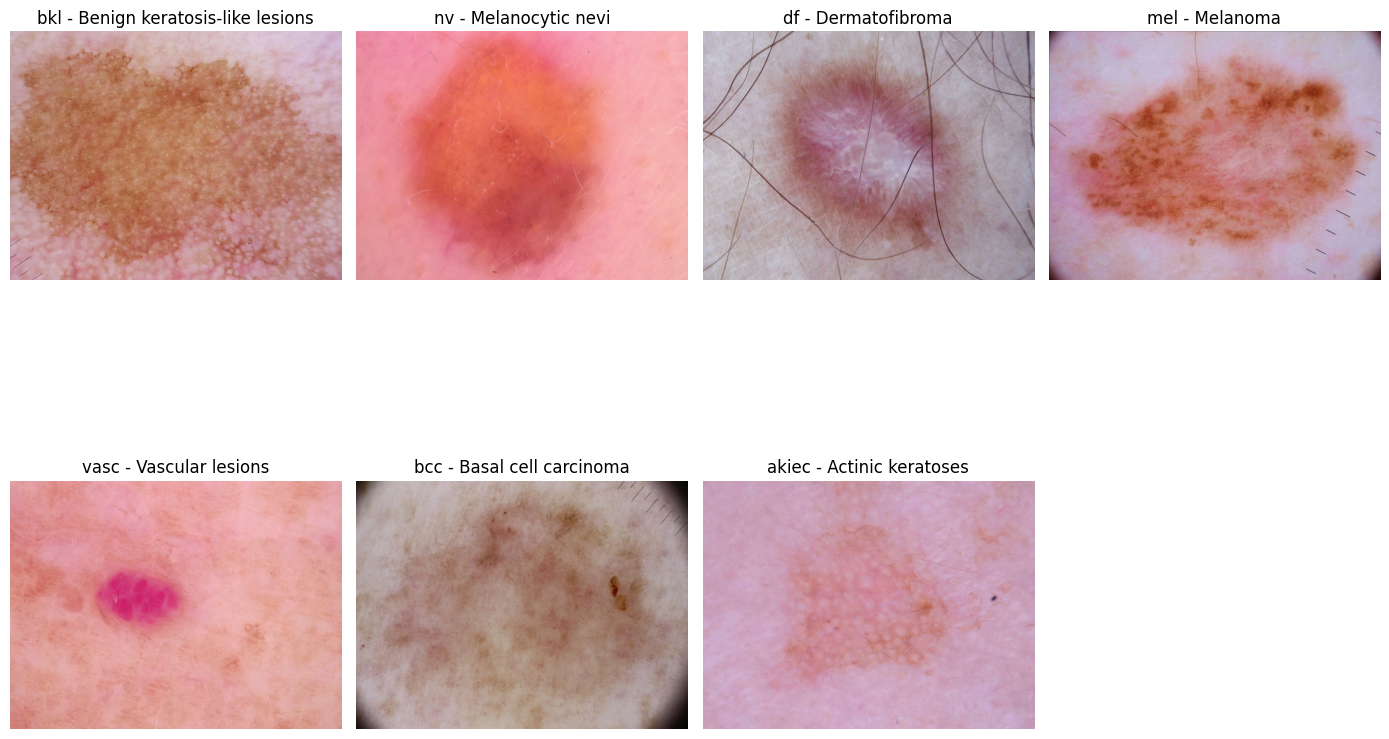

In [4]:
image_path = {}

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if filename.endswith('.jpg'):
            image_id = filename.split('.')[0]
            image_path[image_id] = os.path.join(dirname, filename)

metadata['path'] = metadata['image_id'].map(image_path.get)

print("Total Image Paths Found:", len(image_path))
print("Missing Image Paths:", metadata['path'].isnull().sum())

plt.figure(figsize=(14,10))

classes = metadata['dx'].unique()

for i, class_label in enumerate(classes):
    sample_row = metadata[metadata['dx'] == class_label].sample(1, random_state=42).iloc[0]

    img = cv2.imread(sample_row['path'])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2,4,i+1)
    plt.imshow(img)
    plt.title(class_label + " - " + sample_row['class_name'])
    plt.axis('off')

plt.tight_layout()
plt.savefig("/kaggle/working/figures/sample_images_each_class.png", dpi=300, bbox_inches="tight")

**Image Processing**

In [5]:
IMG_SIZE = 128

X = []
y = []

for _, row in metadata.iterrows():
    img = cv2.imread(row['path'])
    
    if img is None:
        continue
    
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    X.append(img)
    y.append(row['dx'])

X = np.array(X, dtype=np.float32) / 255.0
y = np.array(y)

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
y_categorical = to_categorical(y_encoded)

print("Image Data Shape:", X.shape)
print("Label Shape:", y_categorical.shape)
print("Classes:", label_encoder.classes_)

Image Data Shape: (10015, 128, 128, 3)
Label Shape: (10015, 7)
Classes: ['akiec' 'bcc' 'bkl' 'df' 'mel' 'nv' 'vasc']


**Train, Validation, and Test Split**

In [6]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y_categorical,
    test_size=0.30,
    random_state=42,
    stratify=y_encoded
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=np.argmax(y_temp, axis=1)
)

print("Training Data:", X_train.shape, y_train.shape)
print("Validation Data:", X_val.shape, y_val.shape)
print("Testing Data:", X_test.shape, y_test.shape)

Training Data: (7010, 128, 128, 3) (7010, 7)
Validation Data: (1502, 128, 128, 3) (1502, 7)
Testing Data: (1503, 128, 128, 3) (1503, 7)


**Data Augmentation**

In [7]:
train_datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator()

train_generator = train_datagen.flow(X_train, y_train, batch_size=32)
val_generator = val_datagen.flow(X_val, y_val, batch_size=32)

print("Data Augmentation Ready")

Data Augmentation Ready


**Custom CNN Model**

In [8]:
cnn_model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(7, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

I0000 00:00:1780757185.493737      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780757185.499471      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,306,439 (12.61 MB)

 Trainable params: 3,305,991 (12.61 MB)

 Non-trainable params: 448 (1.75 KB)

**CNN Model Training**

In [9]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

cnn_history = cnn_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[early_stop]
)

Epoch 1/10


I0000 00:00:1780757189.515418     161 service.cc:152] XLA service 0x7c20d8005dd0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780757189.515464     161 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1780757189.515468     161 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1780757190.043942     161 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-06-06 14:46:31.821370: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-06 14:46:31.969494: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  3/220 ━━━━━━━━━━━━━━━━━━━━ 16s 77ms/step - accuracy: 0.3090 - loss: 4.6437

I0000 00:00:1780757194.878676     161 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


220/220 ━━━━━━━━━━━━━━━━━━━━ 38s 136ms/step - accuracy: 0.6019 - loss: 2.3274 - val_accuracy: 0.4820 - val_loss: 1.8098
Epoch 2/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 25s 111ms/step - accuracy: 0.6578 - loss: 1.1937 - val_accuracy: 0.6551 - val_loss: 1.5217
Epoch 3/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 24s 111ms/step - accuracy: 0.6628 - loss: 1.0780 - val_accuracy: 0.6678 - val_loss: 0.8986
Epoch 4/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 25s 112ms/step - accuracy: 0.6658 - loss: 1.0252 - val_accuracy: 0.6698 - val_loss: 0.9675
Epoch 5/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 24s 111ms/step - accuracy: 0.6665 - loss: 1.0009 - val_accuracy: 0.6571 - val_loss: 0.9941
Epoch 6/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 24s 111ms/step - accuracy: 0.6682 - loss: 0.9937 - val_accuracy: 0.6704 - val_loss: 1.0912


**Accuracy And Lost Curves**

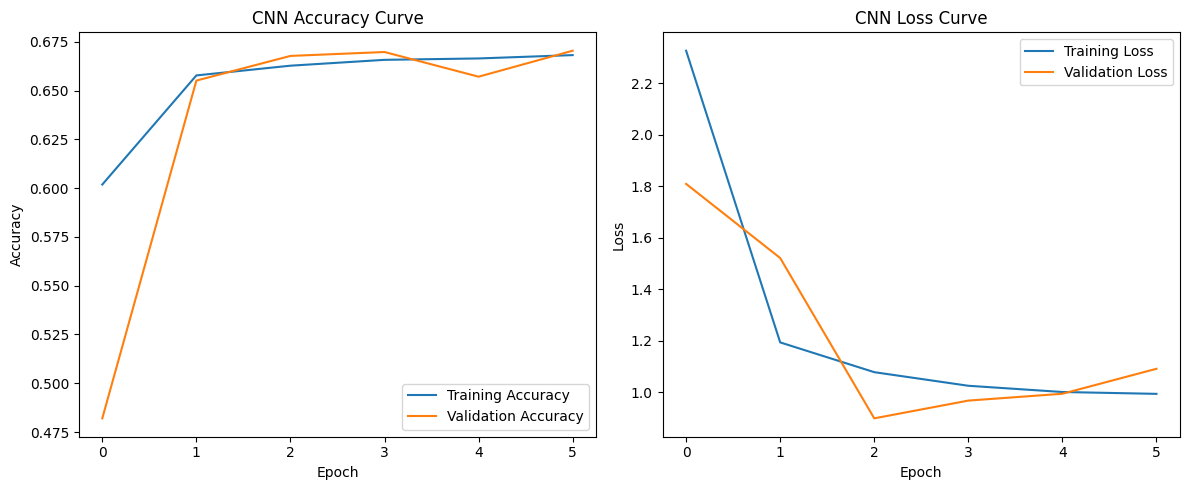

In [10]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(cnn_history.history['accuracy'], label='Training Accuracy')
plt.plot(cnn_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(cnn_history.history['loss'], label='Training Loss')
plt.plot(cnn_history.history['val_loss'], label='Validation Loss')
plt.title('CNN Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig("/kaggle/working/figures/cnn_accuracy_loss_curve.png", dpi=300, bbox_inches="tight")
plt.show()

**Test Evaluation**

In [11]:
test_loss, test_accuracy = cnn_model.evaluate(X_test, y_test)

print("CNN Test Loss:", test_loss)
print("CNN Test Accuracy:", test_accuracy)

47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.6713 - loss: 0.9212
CNN Test Loss: 0.9212408661842346
CNN Test Accuracy: 0.6713240146636963


**Confusion Matrix**

47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step


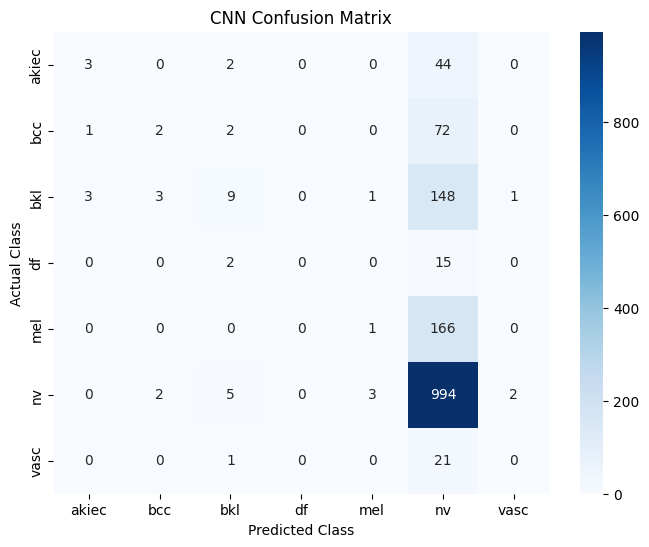

In [12]:
y_pred = cnn_model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.savefig("/kaggle/working/figures/confusion_matrix.png", dpi=300, bbox_inches="tight")

**Classification Report**

In [13]:
report = classification_report(
    y_true_classes,
    y_pred_classes,
    target_names=label_encoder.classes_,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

display(report_df)

report_df.to_csv("/kaggle/working/results/classification_report.csv", index=True)
print("Classification report saved")

,precision,recall,f1-score,support
akiec,0.428571,0.061224,0.107143,49.000000
bcc,0.285714,0.025974,0.047619,77.000000
bkl,0.428571,0.054545,0.096774,165.000000
df,0.000000,0.000000,0.000000,17.000000
mel,0.200000,0.005988,0.011628,167.000000
nv,0.680822,0.988072,0.806164,1006.000000
vasc,0.000000,0.000000,0.000000,22.000000
accuracy,0.671324,0.671324,0.671324,0.671324
macro avg,0.289097,0.162258,0.152761,1503.000000
weighted avg,0.553574,0.671324,0.557437,1503.000000


Classification report saved


**Transfer Learning using MobileNetV2**

In [14]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(128,128,3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)

output = Dense(7, activation='softmax')(x)

mobilenet_model = Model(inputs=base_model.input, outputs=output)

mobilenet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

mobilenet_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 64, 64,    │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 64, 64,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 64, 64,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 64, 64,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 64, 64,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 64, 64,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 65, 65,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 32, 32,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 32, 32,    │      2,304 │ block_1_depthwis

 Total params: 2,422,855 (9.24 MB)

 Trainable params: 164,871 (644.03 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

**Train MobileNetV2**

In [15]:
mobilenet_history = mobilenet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[early_stop]
)

Epoch 1/10


2026-06-06 14:49:28.841173: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-06 14:49:28.977432: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


134/220 ━━━━━━━━━━━━━━━━━━━━ 9s 108ms/step - accuracy: 0.6185 - loss: 1.2508

2026-06-06 14:49:54.331503: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-06 14:49:54.469795: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.6356 - loss: 1.1574

2026-06-06 14:50:18.838791: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-06 14:50:18.980566: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


220/220 ━━━━━━━━━━━━━━━━━━━━ 66s 226ms/step - accuracy: 0.6693 - loss: 0.9845 - val_accuracy: 0.7204 - val_loss: 0.7876
Epoch 2/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 25s 111ms/step - accuracy: 0.7029 - loss: 0.8517 - val_accuracy: 0.7217 - val_loss: 0.7783
Epoch 3/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 25s 111ms/step - accuracy: 0.7098 - loss: 0.8170 - val_accuracy: 0.7317 - val_loss: 0.7585
Epoch 4/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 25s 111ms/step - accuracy: 0.7211 - loss: 0.7941 - val_accuracy: 0.7304 - val_loss: 0.7577
Epoch 5/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 24s 111ms/step - accuracy: 0.7173 - loss: 0.7846 - val_accuracy: 0.7264 - val_loss: 0.7425
Epoch 6/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 24s 110ms/step - accuracy: 0.7270 - loss: 0.7699 - val_accuracy: 0.7337 - val_loss: 0.7489
Epoch 7/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 25s 112ms/step - accuracy: 0.7274 - loss: 0.7630 - val_accuracy: 0.7383 - val_loss: 0.7378
Epoch 8/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 25s 112ms/step - accuracy: 0.7320 - loss: 0.7584 - val

**Evaluate MobileNetV2**

In [16]:
mobile_loss, mobile_accuracy = mobilenet_model.evaluate(
    X_test,
    y_test
)

print("MobileNetV2 Accuracy:", mobile_accuracy)

44/47 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7218 - loss: 0.7698

2026-06-06 14:54:15.901583: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-06 14:54:16.054692: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-06 14:54:16.191366: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


47/47 ━━━━━━━━━━━━━━━━━━━━ 15s 230ms/step - accuracy: 0.7212 - loss: 0.7803
MobileNetV2 Accuracy: 0.7212241888046265


**Model Comparison Table**

In [17]:
comparison = pd.DataFrame({
    'Model': ['Custom CNN', 'MobileNetV2'],
    'Accuracy': [test_accuracy, mobile_accuracy]
})

comparison = comparison.sort_values(
    by='Accuracy',
    ascending=False
)

comparison

,Model,Accuracy
1,MobileNetV2,0.721224
0,Custom CNN,0.671324


**CNN vs MobileNetV2 Comparison Graph**

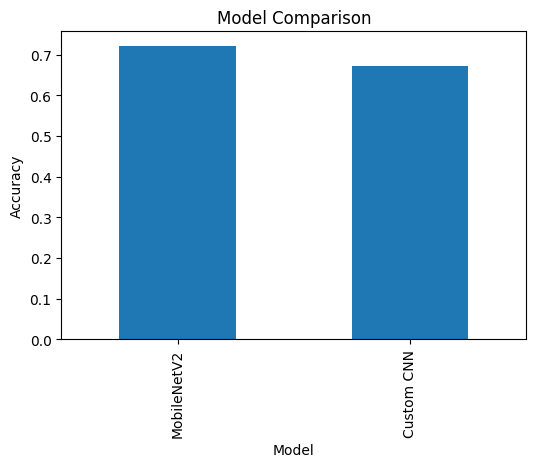

In [18]:
comparison.plot(
    x='Model',
    y='Accuracy',
    kind='bar',
    legend=False,
    figsize=(6,4)
)

plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.savefig("/kaggle/working/figures/model_comparison_graph.png", dpi=300, bbox_inches="tight")

**Grad-CAM Visualization**

**Image Test**

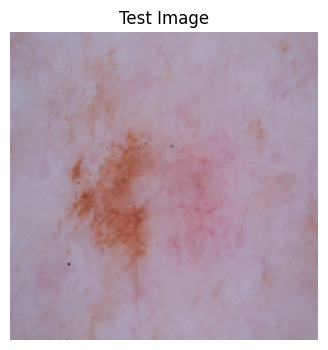

In [19]:
sample_index = 0

img = X_test[sample_index]

plt.figure(figsize=(4,4))
plt.imshow(img)
plt.title("Test Image")
plt.axis('off')
plt.savefig("/kaggle/working/figures/gradcam_overlay.png", dpi=300, bbox_inches="tight")

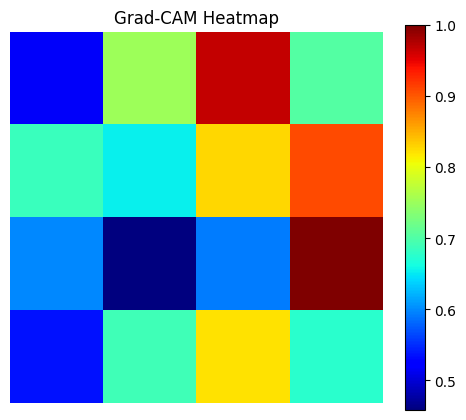

In [20]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

last_conv_layer_name = "Conv_1"

grad_model = tf.keras.models.Model(
    [mobilenet_model.inputs],
    [
        mobilenet_model.get_layer(last_conv_layer_name).output,
        mobilenet_model.output
    ]
)

img_array = np.expand_dims(X_test[0], axis=0)

with tf.GradientTape() as tape:
    conv_outputs, predictions = grad_model(img_array)
    predicted_class = tf.argmax(predictions[0])

    loss = predictions[:, predicted_class]

grads = tape.gradient(loss, conv_outputs)

pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

conv_outputs = conv_outputs[0]

heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
heatmap = tf.squeeze(heatmap)

heatmap = np.maximum(heatmap, 0)
heatmap = heatmap / np.max(heatmap)

plt.figure(figsize=(6,5))
plt.imshow(heatmap, cmap='jet')
plt.colorbar()
plt.title("Grad-CAM Heatmap")
plt.axis('off')
plt.show()

**Overlay Heatmap on Original Image**

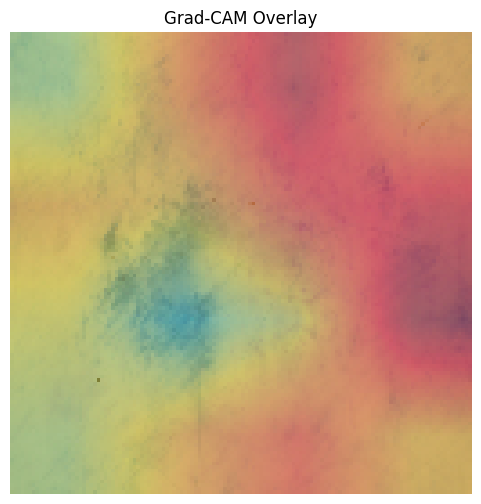

In [21]:
heatmap = cv2.resize(
    heatmap,
    (img.shape[1], img.shape[0])
)

heatmap = np.uint8(255 * heatmap)

heatmap = cv2.applyColorMap(
    heatmap,
    cv2.COLORMAP_JET
)

original = (img * 255).astype(np.uint8)

superimposed_img = cv2.addWeighted(
    original,
    0.6,
    heatmap,
    0.4,
    0
)

plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB))
plt.title("Grad-CAM Overlay")
plt.axis('off')
plt.show()

In [22]:
print("Saved Figures:")
print(os.listdir("/kaggle/working/figures"))

print("\nSaved Tables:")
print(os.listdir("/kaggle/working/results"))

Saved Figures:
['confusion_matrix.png', 'gradcam_overlay.png', 'sample_images_each_class.png', 'cnn_accuracy_loss_curve.png', 'class_distribution.png', 'model_comparison_graph.png']

Saved Tables:
['classification_report.csv']
